# Projet - DATA SCIENCE SALARIES


## Introduction


## Importation et prétraitement des données

In [1]:
# Suppress warnings
import warnings
import sys
warnings.filterwarnings('ignore')
import os
# dataset
import numpy as np
import pandas as pd
# plot
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Preprocessing sklearn 
import sklearn, inspect
from sklearn import metrics

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, mean_absolute_error, accuracy_score, r2_score,f1_score,recall_score
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

#Preprocessing tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

#preprocessing analyse des données du model
import shap

In [2]:
path = os.getcwd()
datafile = path + "//salaries.csv"
df = pd.read_csv(datafile, delimiter= ",")
df = df.dropna()
df.shape

(151445, 11)

In [3]:
print(df.head())

   work_year experience_level employment_type       job_title  salary  \
0       2025               EX              FT    Head of Data  348516   
1       2025               EX              FT    Head of Data  232344   
2       2025               SE              FT  Data Scientist  145400   
3       2025               SE              FT  Data Scientist   81600   
4       2025               MI              FT        Engineer  160000   

  salary_currency  salary_in_usd employee_residence  remote_ratio  \
0             USD         348516                 US             0   
1             USD         232344                 US             0   
2             USD         145400                 US             0   
3             USD          81600                 US             0   
4             USD         160000                 US           100   

  company_location company_size  
0               US            M  
1               US            M  
2               US            M  
3         

In [4]:
df=df.drop(["salary","salary_currency"], axis=1)

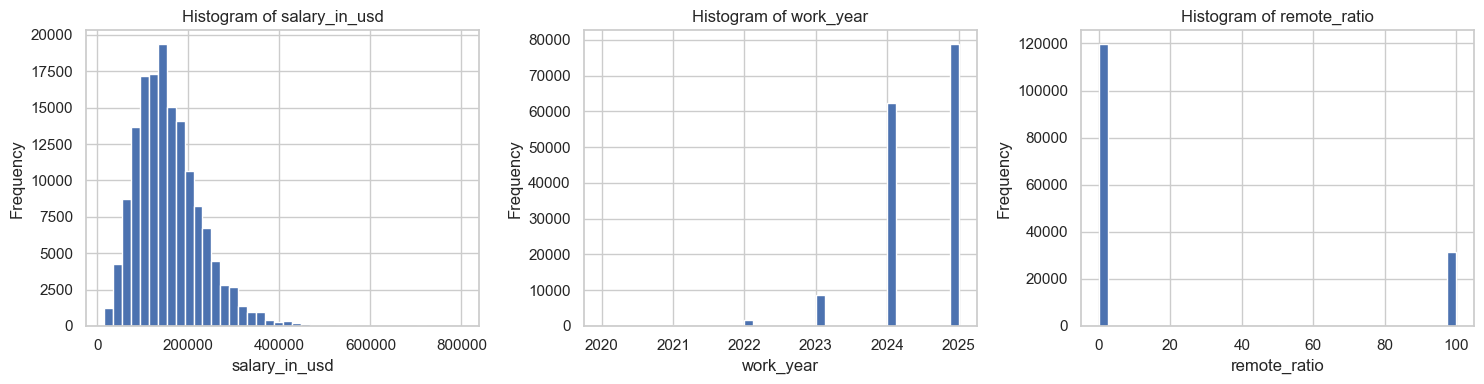

In [5]:
numeric_vars = ["salary_in_usd", "work_year", "remote_ratio"]
plt.figure(figsize=(15, 4))

for i, var in enumerate(numeric_vars, 1):
    plt.subplot(1, len(numeric_vars), i)
    plt.hist(df[var], bins=40)
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [6]:
numeric_vars = [
    "salary_in_usd",
    "work_year",
    "remote_ratio"
]
numeric_summary = df[numeric_vars].describe().T
numeric_summary


,count,mean,std,min,25%,50%,75%,max
salary_in_usd,151445.0,157527.458411,74150.772377,15000.0,105800.0,146100.0,198000.0,800000.0
work_year,151445.0,2024.435313,0.671842,2020.0,2024.0,2025.0,2025.0,2025.0
remote_ratio,151445.0,20.938625,40.620393,0.0,0.0,0.0,0.0,100.0


In [7]:
#sélectionner des différents zones de salaire pour faire des classifications
bins = [0,100000,200000,300000,df["salary_in_usd"].max()]
labels = ['A', 'B', 'C','D']  # labels des différents zones de salaire
df["salary_zone"] = pd.cut(df["salary_in_usd"], bins=bins, labels=labels, right=True)

In [8]:
categorical_vars = [
    "experience_level",
    "employment_type",
    "job_title",
    "employee_residence",
    "company_location",
    "company_size",
    "salary_zone",
    "remote_ratio"   
]

In [9]:
cat_detail = []
for var in categorical_vars:
    counts = df[var].value_counts()
    proportions = counts / len(df) * 100
    
    for level in counts.index:
        cat_detail.append({
            "Variable": var,
            "Modalité": level,
            "Effectif": counts[level],
            "Proportion (%)": round(proportions[level], 2)
        })

cat_detail_df = pd.DataFrame(cat_detail)
cat_detail_df


,Variable,Modalité,Effectif,Proportion (%)
0,experience_level,SE,87491,57.77
1,experience_level,MI,46128,30.46
2,experience_level,EN,13663,9.02
3,experience_level,EX,4163,2.75
4,employment_type,FT,150541,99.40
...,...,...,...,...
636,salary_zone,C,29415,19.42
637,salary_zone,D,5746,3.79
638,remote_ratio,0,119570,78.95
639,remote_ratio,100,31546,20.83


In [10]:


cat_summary = []

for var in categorical_vars:
    counts = df[var].value_counts()
    cat_summary.append({
        "Variable": var,
        "Nombre de modalités": counts.shape[0],
        "Modalité principale": counts.index[0],
        "Effectif modalité principale": counts.iloc[0],
        "Proportion (%)": round(counts.iloc[0] / len(df) * 100, 2)
    })

cat_summary_df = pd.DataFrame(cat_summary)
cat_summary_df

,Variable,Nombre de modalités,Modalité principale,Effectif modalité principale,Proportion (%)
0,experience_level,4,SE,87491,57.77
1,employment_type,4,FT,150541,99.40
2,job_title,422,Data Scientist,18751,12.38
3,employee_residence,104,US,135506,89.48
4,company_location,97,US,135569,89.52
5,company_size,3,M,147302,97.26
6,salary_zone,4,B,81748,53.98
7,remote_ratio,3,0,119570,78.95


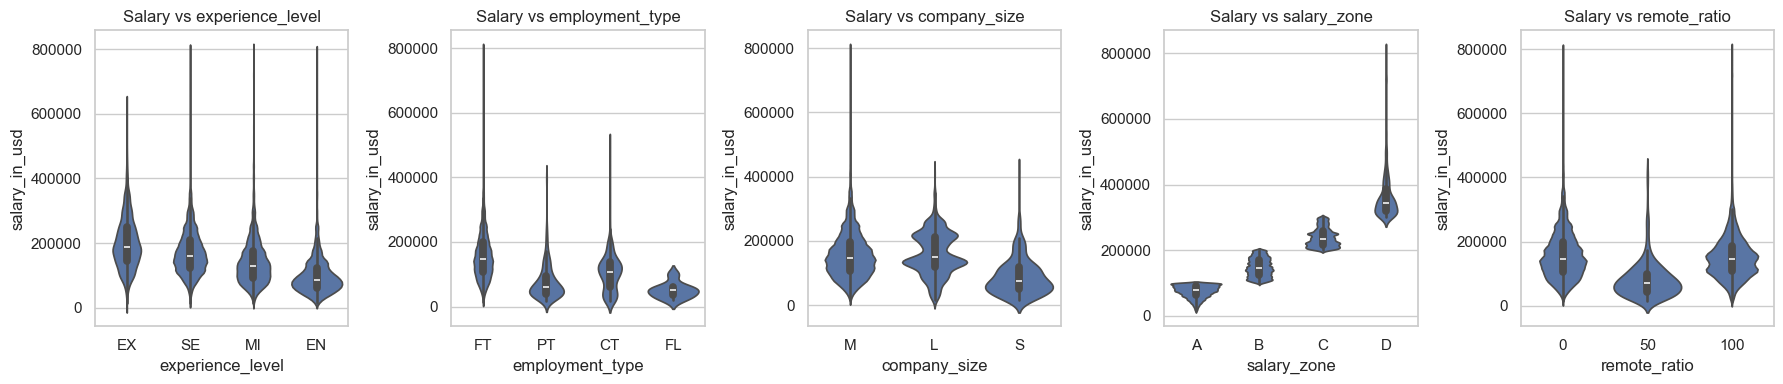

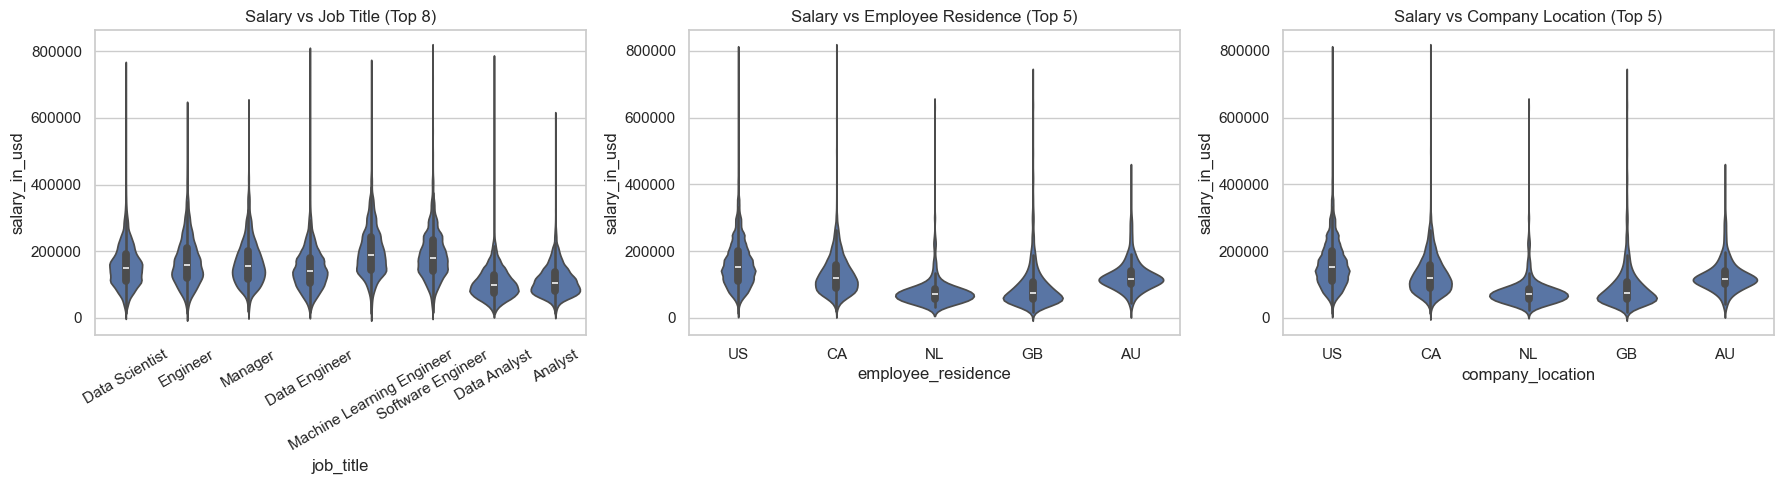

In [11]:
top_jobs = df["job_title"].value_counts().head(8).index
df_job = df[df["job_title"].isin(top_jobs)].copy()

top_residence = df["employee_residence"].value_counts().head(5).index
df_residence = df[df["employee_residence"].isin(top_residence)].copy()

top_location = df["company_location"].value_counts().head(5).index
df_location = df[df["company_location"].isin(top_location)].copy()

cat_vars_violin = [
    "experience_level",
    "employment_type",
    "company_size",
    "salary_zone",
    "remote_ratio"
]

plt.figure(figsize=(18, 4))

for i, var in enumerate(cat_vars_violin, 1):
    plt.subplot(1, len(cat_vars_violin), i)
    sns.violinplot(data=df, x=var, y="salary_in_usd")
    plt.title(f"Salary vs {var}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(
    data=df_job,
    x="job_title",
    y="salary_in_usd",
    ax=axes[0]
)
axes[0].set_title("Salary vs Job Title (Top 8)")
axes[0].tick_params(axis="x", rotation=30)

sns.violinplot(
    data=df_residence,
    x="employee_residence",
    y="salary_in_usd",
    ax=axes[1]
)
axes[1].set_title("Salary vs Employee Residence (Top 5)")

sns.violinplot(
    data=df_location,
    x="company_location",
    y="salary_in_usd",
    ax=axes[2]
)
axes[2].set_title("Salary vs Company Location (Top 5)")

plt.tight_layout()
plt.show()

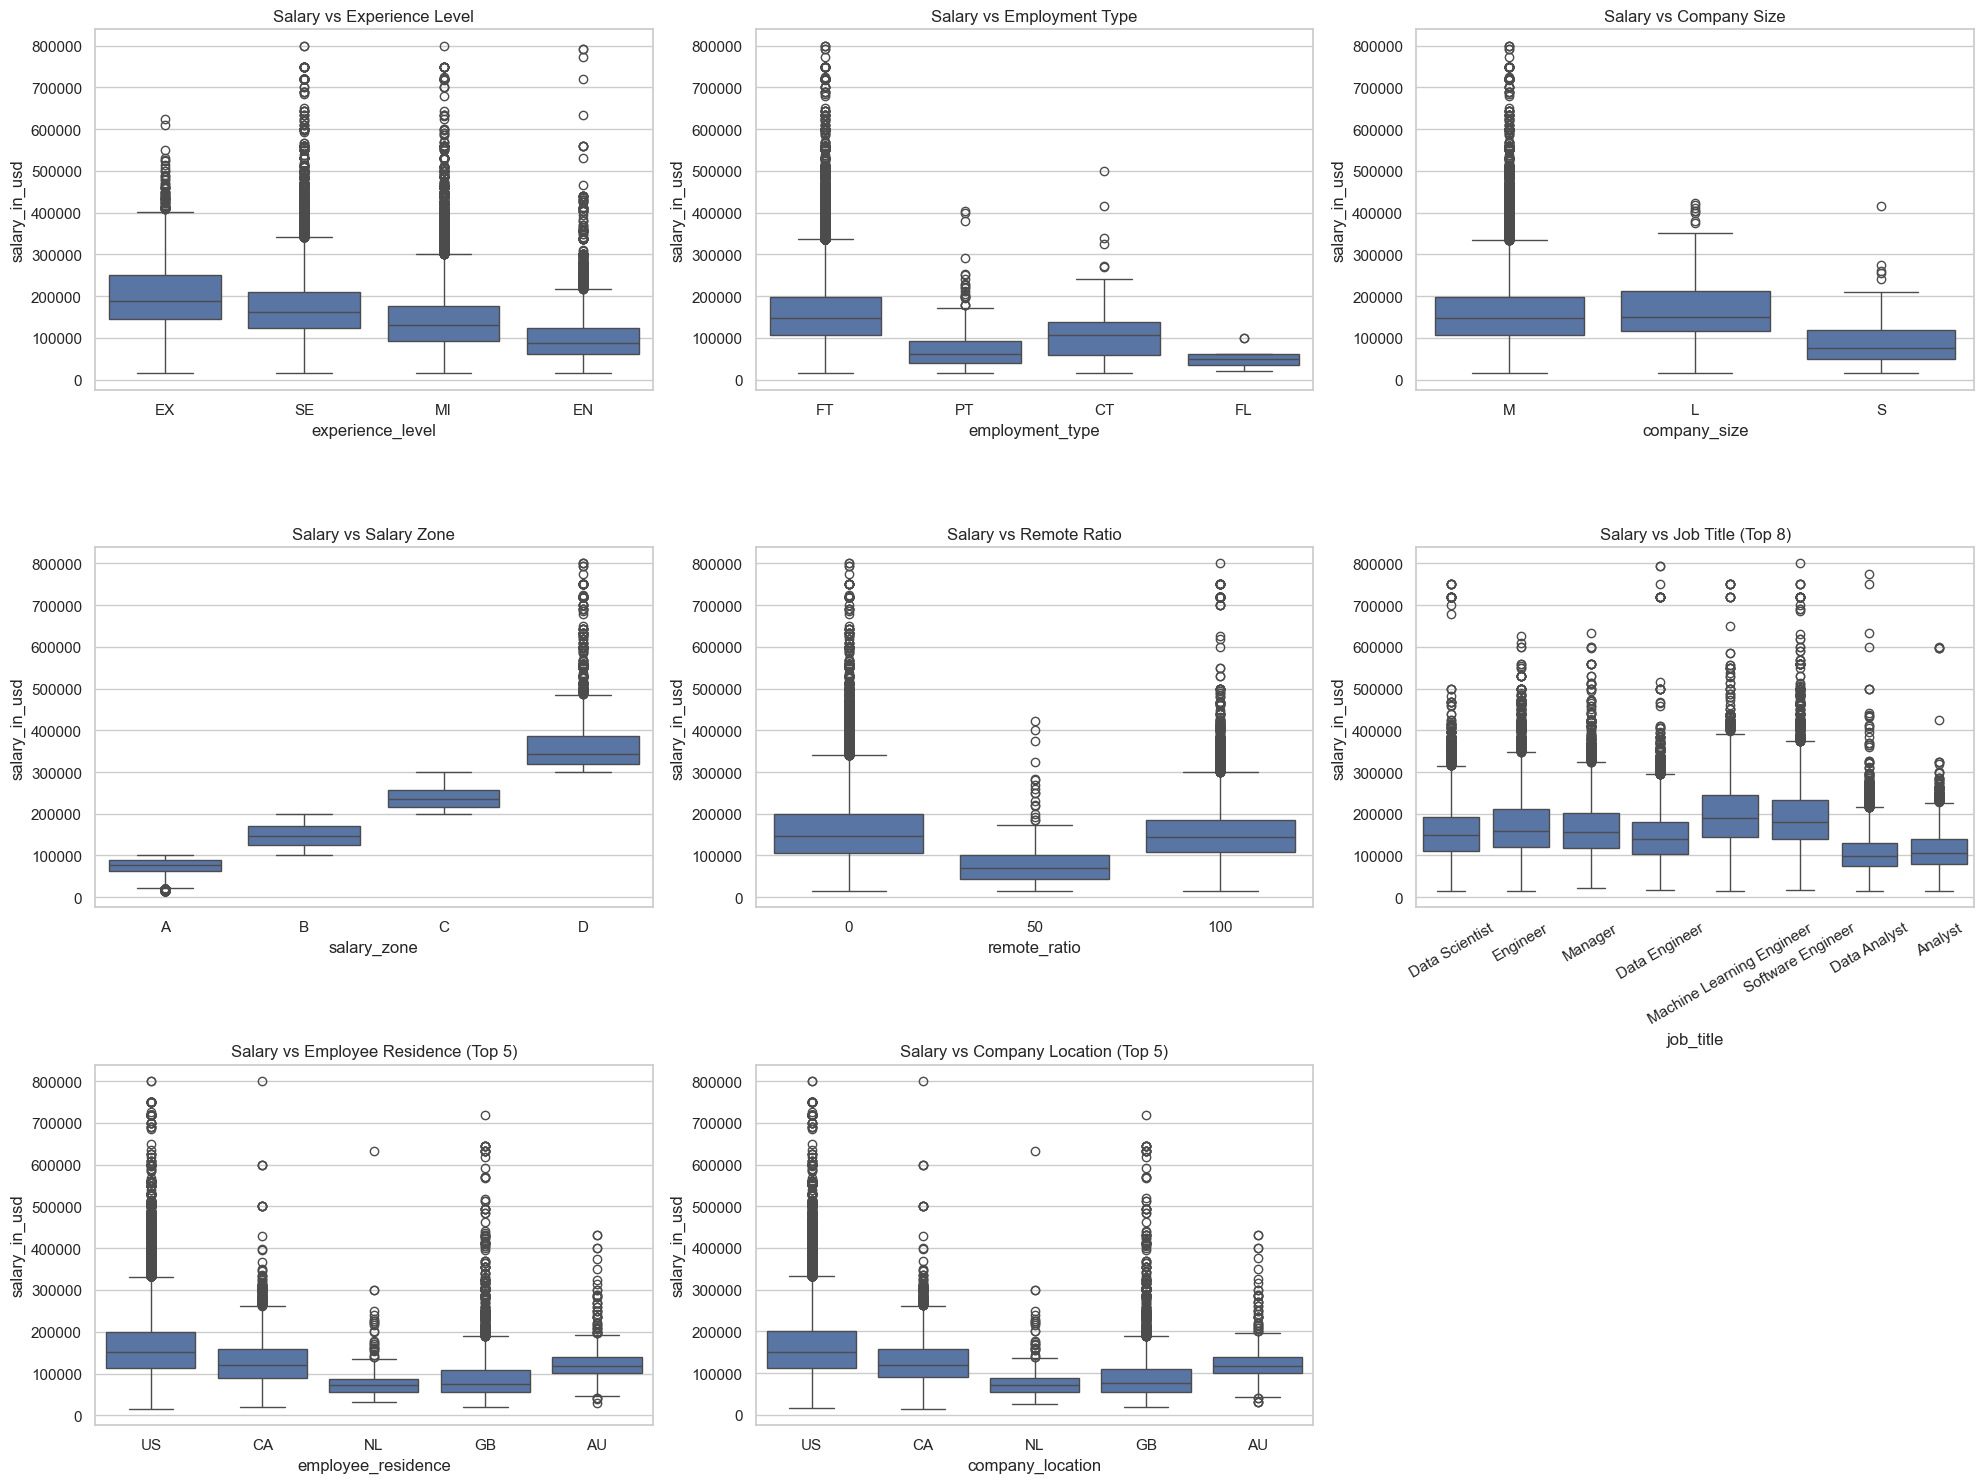

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()

sns.boxplot(data=df, x="experience_level", y="salary_in_usd", ax=axes[0])
axes[0].set_title("Salary vs Experience Level")

sns.boxplot(data=df, x="employment_type", y="salary_in_usd", ax=axes[1])
axes[1].set_title("Salary vs Employment Type")

sns.boxplot(data=df, x="company_size", y="salary_in_usd", ax=axes[2])
axes[2].set_title("Salary vs Company Size")

sns.boxplot(data=df, x="salary_zone", y="salary_in_usd", ax=axes[3])
axes[3].set_title("Salary vs Salary Zone")

sns.boxplot(data=df, x="remote_ratio", y="salary_in_usd", ax=axes[4])
axes[4].set_title("Salary vs Remote Ratio")

sns.boxplot(data=df_job, x="job_title", y="salary_in_usd", ax=axes[5])
axes[5].set_title("Salary vs Job Title (Top 8)")
axes[5].tick_params(axis="x", rotation=30)

sns.boxplot(data=df_residence, x="employee_residence", y="salary_in_usd", ax=axes[6])
axes[6].set_title("Salary vs Employee Residence (Top 5)")

sns.boxplot(data=df_location, x="company_location", y="salary_in_usd", ax=axes[7])
axes[7].set_title("Salary vs Company Location (Top 5)")

fig.delaxes(axes[8])
plt.tight_layout()
plt.show()


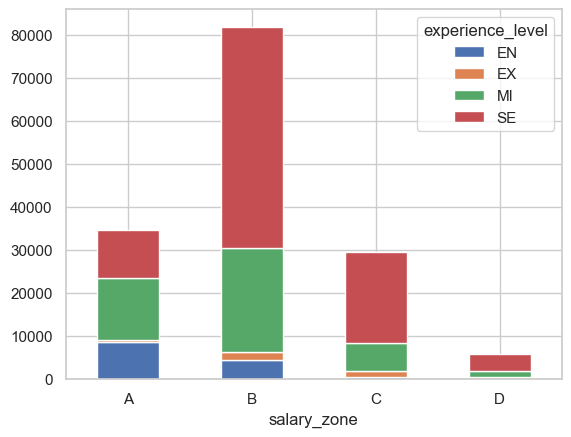

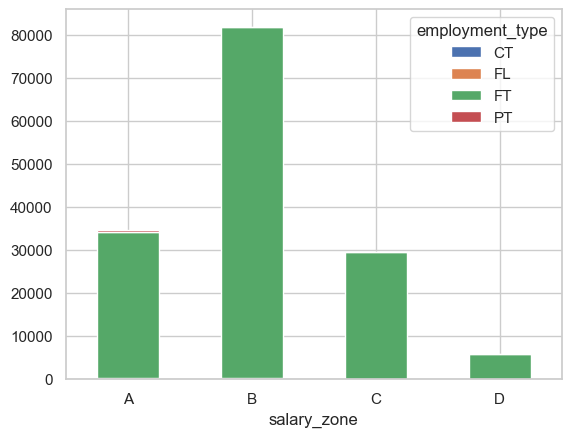

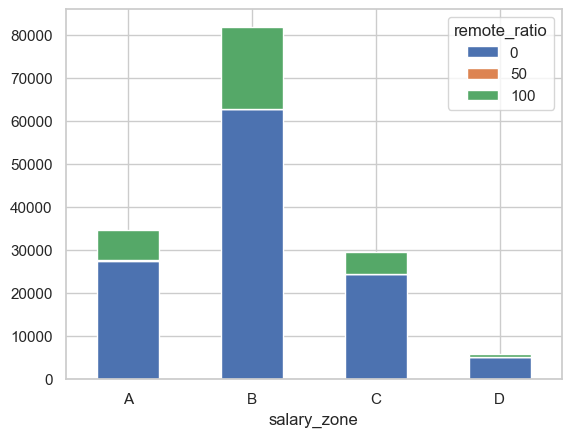

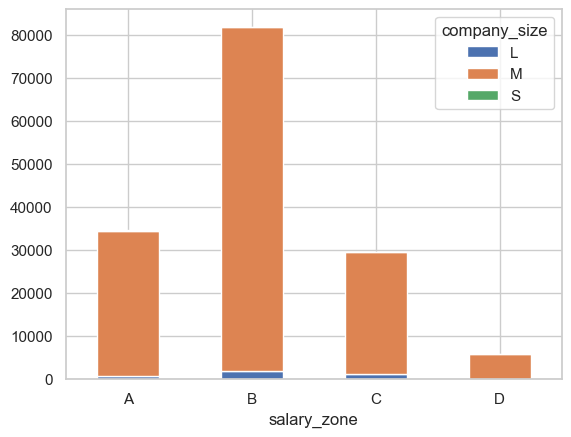

In [13]:
colums = df.columns.drop(["work_year",'salary_in_usd',"salary_zone","job_title","company_location","employee_residence"])
for i in colums:
    df_crosstab = pd.crosstab(df["salary_zone"],df[i])
    df_crosstab.plot(kind="bar", stacked=True, rot=0)

In [14]:
variables = [
    "company_location",
    "experience_level",
    "employment_type",
    "job_title",
    "company_size",
    "remote_ratio",
    "employee_residence",
    "work_year"
]

results = {}
for var in variables:
    top_values = df[var].value_counts().head(10).index

    mean_salary = (
        df[df[var].isin(top_values)]
        .groupby(var, as_index=False)["salary_in_usd"]
        .mean()
        .sort_values("salary_in_usd", ascending=False)
        .round(2)
    )

    mean_salary.columns = [var, "Mean salary (USD)"]

    print(f"\n{var.upper()}")
    print("-" * len(var))

    display(
        mean_salary.style
        .format({"Mean salary (USD)": "{:,.2f}"})
        .set_properties(**{
            "text-align": "left"
        })
        .set_properties(
            subset=["Mean salary (USD)"],
            **{"text-align": "right"}
        )
    )







COMPANY_LOCATION
----------------


,company_location,Mean salary (USD)
9,US,"163,905.31"
2,CA,"129,619.73"
1,AU,"127,974.48"
3,DE,"103,658.79"
6,GB,"95,031.26"
8,NL,"78,332.52"
5,FR,"68,972.45"
4,ES,"64,029.91"
7,LT,"59,626.11"
0,AT,"58,460.29"



EXPERIENCE_LEVEL
----------------


,experience_level,Mean salary (USD)
1,EX,"200,471.43"
3,SE,"172,657.76"
2,MI,"142,301.18"
0,EN,"98,961.74"



EMPLOYMENT_TYPE
---------------


...

,remote_ratio,Mean salary (USD)
0,0,"159,382.78"
2,100,"151,285.86"
1,50,"81,711.63"



EMPLOYEE_RESIDENCE
------------------


,employee_residence,Mean salary (USD)
9,US,"163,945.00"
2,CA,"129,644.12"
1,AU,"128,507.65"
3,DE,"105,016.29"
6,GB,"95,072.47"
8,NL,"78,366.28"
5,FR,"69,062.03"
4,ES,"64,772.94"
7,LT,"59,626.11"
0,AT,"58,457.46"



WORK_YEAR
---------


,work_year,Mean salary (USD)
4,2024,"159,589.56"
5,2025,"157,018.98"
3,2023,"153,682.16"
2,2022,"134,146.47"
0,2020,"102,250.87"
1,2021,"99,922.07"


In [15]:
anova_results = []

for var in variables:
    model = ols(f"salary_in_usd ~ C({var})", data=df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)

    ss_between = anova_table.loc[f"C({var})", "sum_sq"]
    ss_residual = anova_table.loc["Residual", "sum_sq"]
    ss_total = ss_between + ss_residual

    eta_sq = ss_between / ss_total

    anova_results.append({
        "Variable": var,
        "F-statistic": anova_table.loc[f"C({var})", "F"],
        "p-value": anova_table.loc[f"C({var})", "PR(>F)"],
        "Eta squared": eta_sq
    })

anova_df = (
    pd.DataFrame(anova_results)
    .sort_values("Eta squared", ascending=False)
    .reset_index(drop=True)
)

display(
    anova_df.style
    .format({
        "F-statistic": "{:.2f}",
        "p-value": "{:.3e}",
        "Eta squared": "{:.4f}"
    })
)




,Variable,F-statistic,p-value,Eta squared
0,job_title,89.22,0.000e+00,0.1992
1,experience_level,5758.63,0.000e+00,0.1024
2,employee_residence,124.73,0.000e+00,0.0782
3,company_location,132.57,0.000e+00,0.0776
4,employment_type,262.40,7.195e-170,0.0052
5,remote_ratio,322.52,1.695e-140,0.0042
6,work_year,82.85,3.294e-87,0.0027
7,company_size,97.18,6.643e-43,0.0013


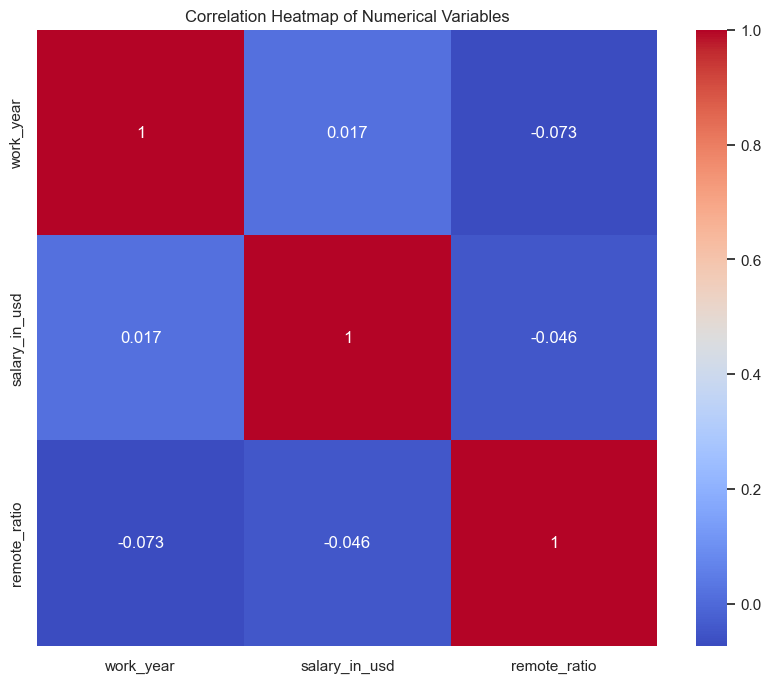

In [16]:
numeric_cols = df.select_dtypes(include=['number']).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()



### one hot encoding and split set

In [17]:
df.shape

(151445, 10)

In [18]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_in_usd', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size', 'salary_zone'],
      dtype='object')

In [19]:
#pretraitement des données


numeric_features = df.select_dtypes(include=['int64', 'float64']).columns 
categorical_features = df.select_dtypes(include=['object']).columns 

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded_array = encoder.fit_transform(df[categorical_features]) #one hot encoding applique sur les features catégorielle

encoded_colnames = encoder.get_feature_names_out(categorical_features)
df_encoded = pd.concat([
    pd.DataFrame(encoded_array, columns=encoded_colnames, index=df.index),
    df[numeric_features].reset_index(drop=True)
], axis=1) #regroupement


In [20]:
#séparation des ensembles
indices = np.arange(df.shape[0])
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
X = df_encoded.drop(columns=['salary_in_usd', 'salary_zone'], errors='ignore')

y_reg = df["salary_in_usd"]#le label continu pour regression
y_clas = df['salary_zone'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3})#le label discret pour classification

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
#normalization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Y_reg_train, Y_reg_test= y_reg.iloc[train_idx],y_reg.iloc[test_idx]
Y_clas_train, Y_clas_test= y_clas.iloc[train_idx],y_clas.iloc[test_idx]

## Les premières modèles 

### Forêt d'aléatoire

#### Regression par forêt d'aléatoire

In [21]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,      
    max_depth=20,          
    min_samples_split=5,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1,             
    verbose=1              
)

rf_regressor.fit(X_train, Y_reg_train)
# prévision
Y_pred_reg = rf_regressor.predict(X_test)

# erreur
rmse = np.sqrt(mean_squared_error(Y_reg_test, Y_pred_reg))
mae = mean_absolute_error(Y_reg_test, Y_pred_reg)
r2 = r2_score(Y_reg_test, Y_pred_reg)

print(f"\nperformance du modèle de régression:")
print(f"  RMSE: ${rmse:,.2f}")
print(f"  MAE:  ${mae:,.2f}")
print(f"  R²:   {r2:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.



performance du modèle de régression:
  RMSE: $62,600.88
  MAE:  $45,660.09
  R²:   0.2945


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   14.2s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


#### Classification par forêt d'aléatoire

In [22]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,      
    max_depth=20,          
    min_samples_split=5,   
    min_samples_leaf=2,    
    random_state=42,
    n_jobs=-1,             
    verbose=1              
)


rf_classifier.fit(X_train, Y_clas_train)


Y_pred_clas_forest = rf_classifier.predict(X_test)


accuracy = accuracy_score(Y_clas_test, Y_pred_clas_forest)
f1_macro_rf = f1_score(Y_clas_test, Y_pred_clas_forest, average='macro')

print(f"\nperformance du modèle de classification:")
print(f"  accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  F1 score: {f1_macro_rf:.4f}")

print(f"\nrapport:")
target_names = ['A ($0-100k)', 'B ($100-200k)', 'C ($200-300k)', 'D ($300k+)']
print(classification_report(Y_clas_test, Y_pred_clas_forest, target_names=target_names))


cm = confusion_matrix(Y_clas_test, Y_pred_clas_forest)
print(f"\nmatrice de confusion:")
print(cm)

feature_importance_clas = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nLes dix caractéristiques les plus importantes:")
print(feature_importance_clas.head(10).to_string(index=False))


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.



performance du modèle de classification:
  accuracy: 0.5952 (59.52%)
  F1 score: 0.3048

rapport:
               precision    recall  f1-score   support

  A ($0-100k)       0.73      0.38      0.50      6778
B ($100-200k)       0.58      0.95      0.72     16303
C ($200-300k)       0.00      0.00      0.00      6022
   D ($300k+)       0.00      0.00      0.00      1186

     accuracy                           0.60     30289
    macro avg       0.33      0.33      0.30     30289
 weighted avg       0.47      0.60      0.50     30289


matrice de confusion:
[[ 2598  4180     0     0]
 [  873 15430     0     0]
 [   82  5940     0     0]
 [   25  1161     0     0]]

Les dix caractéristiques les plus importantes:
                            feature  importance
                experience_level_EN    0.136922
                experience_level_SE    0.116101
              employee_residence_US    0.094965
                company_location_US    0.092377
             job_title_Data Analyst   

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.1s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


Le modèle est fortement impacté par un déséquilibre important des classes : la classe B représente près de 54 % du jeu de données, tandis que la classe D n’en constitue qu’environ 4 %.
Dans ce contexte, l’algorithme adopte naturellement une stratégie biaisée vers la classe majoritaire, car cette prédiction minimise globalement l’erreur de classification.

En conséquence, le modèle prédit très rarement les classes minoritaires C et D, ce qui conduit à un rappel nul (recall = 0.00) pour ces catégories. Cela indique que le modèle ne parvient pas à identifier les exemples appartenant aux classes rares, ce qui est symptomatique d’un problème classique d’apprentissage sur données déséquilibrées.

In [23]:





rf_balanced = RandomForestClassifier(
    n_estimators=100,      
    max_depth=20,          
    min_samples_split=5,   
    min_samples_leaf=2,    
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,             
    verbose=1              
)
rf_balanced.fit(X_train, Y_clas_train)


Y_pred_clas_forest_balanced = rf_balanced.predict(X_test)


accuracy = accuracy_score(Y_clas_test, Y_pred_clas_forest_balanced)
f1_macro_rf_balenced = f1_score(Y_clas_test, Y_pred_clas_forest_balanced, average='macro')

print(f"\nperformance du modèle de classification:")
print(f"  accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  F1 score: {f1_macro_rf_balenced:.4f}")

print(f"\n rapport:")
print(classification_report(Y_clas_test, Y_pred_clas_forest_balanced, target_names=target_names))


cm = confusion_matrix(Y_clas_test, Y_pred_clas_forest_balanced)
print(f"\nmatrice de confusion:")
print(cm)


feature_importance_clas = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nLes dix caractéristiques les plus importantes:")
print(feature_importance_clas.head(10).to_string(index=False))



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.



performance du modèle de classification:
  accuracy: 0.3619 (36.19%)
  F1 score: 0.3347

 rapport:
               precision    recall  f1-score   support

  A ($0-100k)       0.45      0.78      0.57      6778
B ($100-200k)       0.70      0.19      0.30     16303
C ($200-300k)       0.28      0.30      0.29      6022
   D ($300k+)       0.10      0.68      0.18      1186

     accuracy                           0.36     30289
    macro avg       0.38      0.49      0.33     30289
 weighted avg       0.54      0.36      0.35     30289


matrice de confusion:
[[5257  614  553  354]
 [5355 3105 3858 3985]
 [ 871  635 1795 2721]
 [ 122   59  199  806]]

Les dix caractéristiques les plus importantes:
                            feature  importance
                experience_level_EN    0.136922
                experience_level_SE    0.116101
              employee_residence_US    0.094965
                company_location_US    0.092377
             job_title_Data Analyst    0.079691
     

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.1s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


## Boosting

In [24]:
import xgboost as xgb
import lightgbm as lgb
xgb_reg = xgb.XGBRegressor(
    n_estimators=200,        
    max_depth=8,             
    learning_rate=0.1,       
    subsample=0.8,           
    colsample_bytree=0.8,    
    random_state=42,
    n_jobs=-1
)



xgb_reg.fit(X_train, Y_reg_train)

Y_pred_xgb_reg = xgb_reg.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(Y_reg_test, Y_pred_xgb_reg))
mae_xgb = mean_absolute_error(Y_reg_test, Y_pred_xgb_reg)
r2_xgb = r2_score(Y_reg_test, Y_pred_xgb_reg)

print(f"\nperformance du modèle de régression XGBoost:")
print(f"  RMSE: ${rmse_xgb:,.2f}")
print(f"  MAE:  ${mae_xgb:,.2f}")
print(f"  R²:   {r2_xgb:.4f}")


lgb_reg = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


lgb_reg.fit(X_train, Y_reg_train)

Y_pred_lgb_reg = lgb_reg.predict(X_test)

rmse_lgb = np.sqrt(mean_squared_error(Y_reg_test, Y_pred_lgb_reg))
mae_lgb = mean_absolute_error(Y_reg_test, Y_pred_lgb_reg)
r2_lgb = r2_score(Y_reg_test, Y_pred_lgb_reg)

print(f"\nperformance du modèle de régression par LightGBM:")
print(f"  RMSE: ${rmse_lgb:,.2f}")
print(f"  MAE:  ${mae_lgb:,.2f}")
print(f"  R²:   {r2_lgb:.4f}")


performance du modèle de régression XGBoost:
  RMSE: $61,785.92
  MAE:  $45,011.34
  R²:   0.3128

performance du modèle de régression par LightGBM:
  RMSE: $61,953.92
  MAE:  $45,146.05
  R²:   0.3090


In [25]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)



from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(Y_clas_train), y=Y_clas_train)
sample_weights = np.array([class_weights[y] for y in Y_clas_train])

xgb_clf.fit(X_train, Y_clas_train, sample_weight=sample_weights)

Y_pred_xgb_clf = xgb_clf.predict(X_test)

acc_xgb = accuracy_score(Y_clas_test, Y_pred_xgb_clf)
f1_macro_xgb = f1_score(Y_clas_test, Y_pred_xgb_clf, average='macro')
print(f"\nperformance du modèle de classification par XGBoost:")
print(f"  accuracy: {acc_xgb:.4f} ({acc_xgb*100:.2f}%)")
print(f"  F1 score: {f1_macro_xgb:.4f}")

print(f"\nrapport:")
print(classification_report(Y_clas_test, Y_pred_xgb_clf, 
                          target_names=['A ($0-10万)', 'B ($10-20万)', 'C ($20-30万)', 'D ($30万+)'],
                          zero_division=0))

feature_importance_clas = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nLes dix caractéristiques les plus importantes:")
print(feature_importance_clas.head(10).to_string(index=False))


performance du modèle de classification par XGBoost:
  accuracy: 0.4158 (41.58%)
  F1 score: 0.3746

rapport:
              precision    recall  f1-score   support

  A ($0-10万)       0.51      0.73      0.60      6778
 B ($10-20万)       0.68      0.33      0.44     16303
 C ($20-30万)       0.32      0.25      0.28      6022
   D ($30万+)       0.10      0.70      0.18      1186

    accuracy                           0.42     30289
   macro avg       0.40      0.50      0.37     30289
weighted avg       0.55      0.42      0.43     30289


Les dix caractéristiques les plus importantes:
                            feature  importance
             job_title_Data Analyst    0.049624
                  job_title_Analyst    0.022393
          job_title_Data Specialist    0.018274
            job_title_Data Engineer    0.017124
      job_title_Engineering Manager    0.017011
        job_title_Research Engineer    0.016666
       job_title_Research Scientist    0.016568
job_title_Machine Lear

In [26]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


lgb_clf.fit(X_train, Y_clas_train)

Y_pred_lgb_clf = lgb_clf.predict(X_test)

acc_lgb = accuracy_score(Y_clas_test, Y_pred_lgb_clf)
f1_macro_lgb = f1_score(Y_clas_test, Y_pred_lgb_clf, average='macro')

print(f"\nperformance du modèle de classification par LightGBM:")
print(f"  accuracy: {acc_lgb:.4f} ({acc_lgb*100:.2f}%)")
print(f"  F1 score: {f1_macro_lgb:.4f}")

print(f"\nrapport:")
print(classification_report(Y_clas_test, Y_pred_lgb_clf, 
                          target_names=target_names,
                          zero_division=0))
feature_importance_clas = pd.DataFrame({
    'feature': X.columns,
    'importance': lgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nLes dix caractéristiques les plus importantes:")
print(feature_importance_clas.head(10).to_string(index=False))


performance du modèle de classification par LightGBM:
  accuracy: 0.4139 (41.39%)
  F1 score: 0.3737

rapport:
               precision    recall  f1-score   support

  A ($0-100k)       0.50      0.74      0.60      6778
B ($100-200k)       0.68      0.32      0.43     16303
C ($200-300k)       0.31      0.26      0.28      6022
   D ($300k+)       0.10      0.67      0.18      1186

     accuracy                           0.41     30289
    macro avg       0.40      0.50      0.37     30289
 weighted avg       0.55      0.41      0.43     30289


Les dix caractéristiques les plus importantes:
                            feature  importance
                          work_year        3068
                       remote_ratio        1960
                experience_level_SE        1809
                experience_level_MI        1482
              employee_residence_US         926
                experience_level_EN         648
                experience_level_EX         536
             

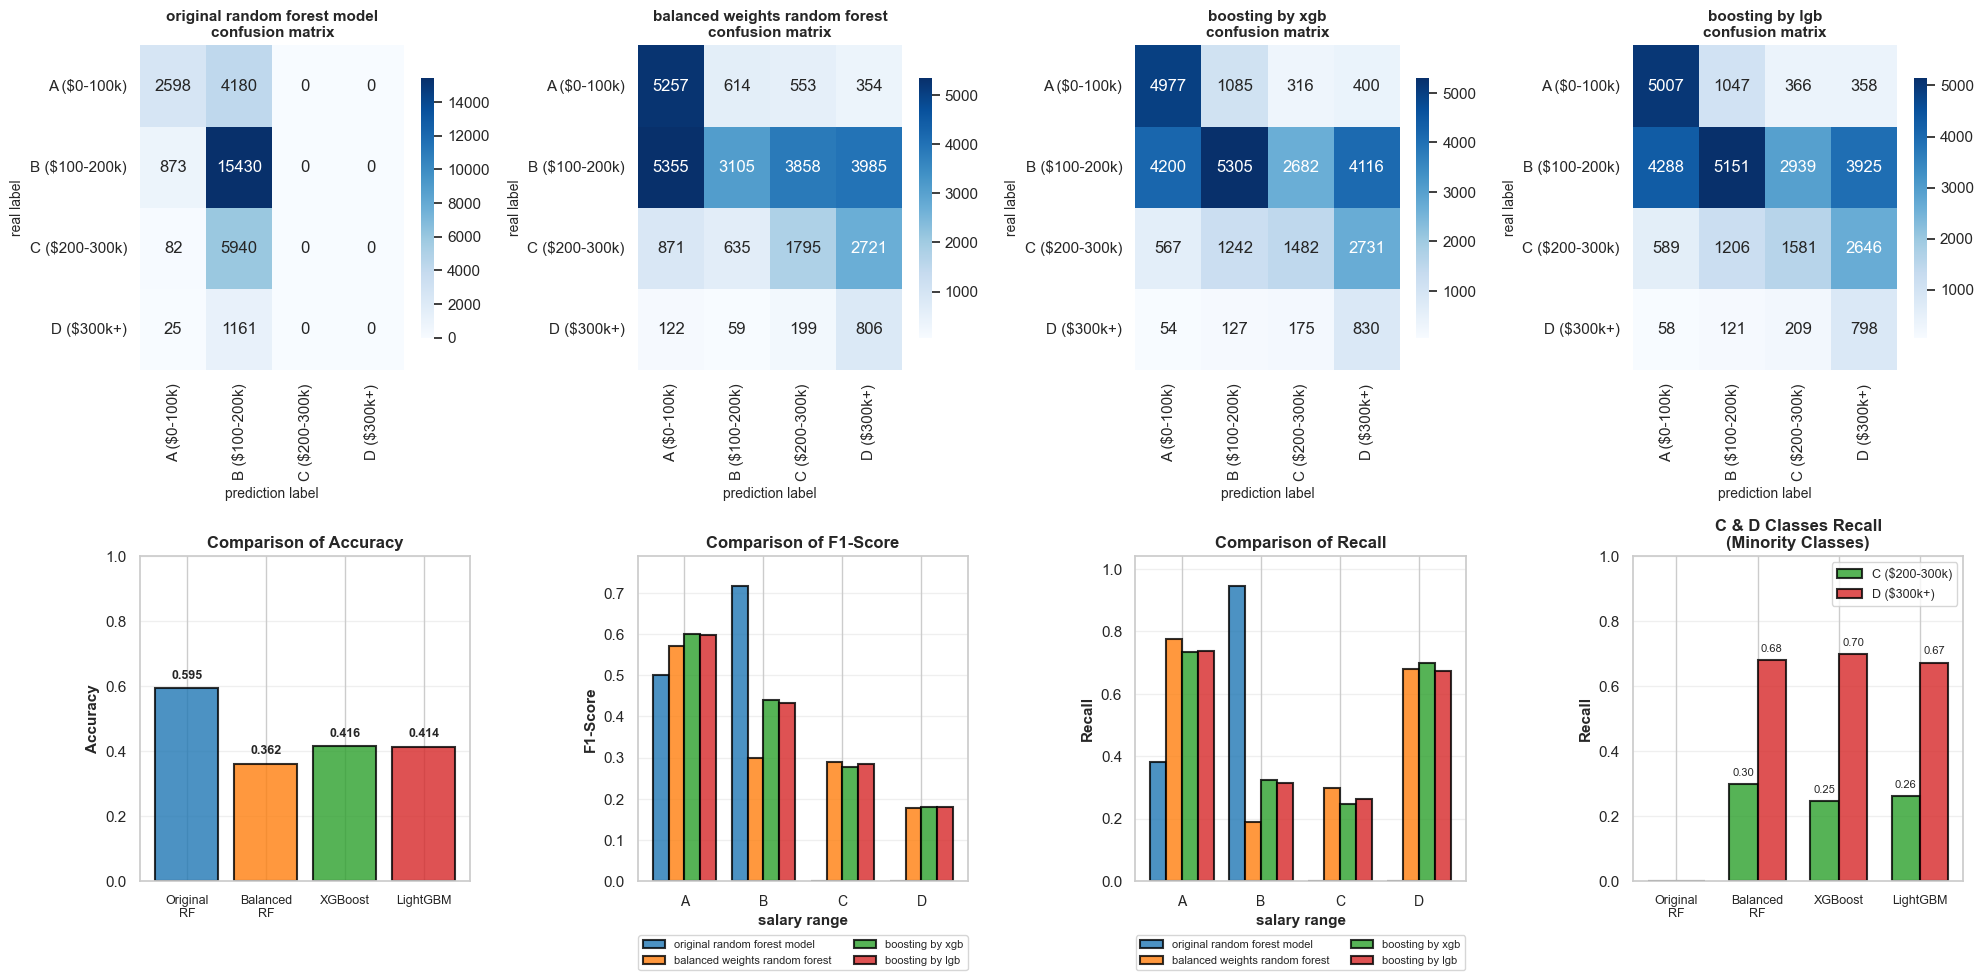

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))  



models = [
    ('original random forest model', Y_pred_clas_forest),
    ('balanced weights random forest', Y_pred_clas_forest_balanced),
    ('boosting by xgb', Y_pred_xgb_clf),
    ('boosting by lgb', Y_pred_lgb_clf)
]

for idx, (name, y_pred) in enumerate(models):
    ax = axes[0, idx]
    cm = confusion_matrix(Y_clas_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'{name}\nconfusion matrix', fontsize=11, fontweight='bold')
    ax.set_xlabel('prediction label', fontsize=10)
    ax.set_ylabel('real label', fontsize=10)


f1_scores = []
recalls = []
for name, y_pred in models:
    f1 = f1_score(Y_clas_test, y_pred, average=None)
    recall = recall_score(Y_clas_test, y_pred, average=None)
    f1_scores.append(f1)
    recalls.append(recall)

x = np.arange(4)
width = 0.2  
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 


ax = axes[1, 1]
for i, (name, _) in enumerate(models):
    
    ax.bar(x + i*width - 1.5*width, f1_scores[i], width, 
           label=name, color=colors[i], alpha=0.8, 
           edgecolor='black', linewidth=1.5)

ax.set_xlabel('salary range', fontsize=11, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax.set_title('Comparison of F1-Score', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['A', 'B', 'C', 'D'], fontsize=10)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=2, fontsize=8, frameon=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, max([max(f1) for f1 in f1_scores]) * 1.1])


ax = axes[1, 2]
for i, (name, _) in enumerate(models):
    ax.bar(x + i*width - 1.5*width, recalls[i], width, 
           label=name, color=colors[i], alpha=0.8,
           edgecolor='black', linewidth=1.5)

ax.set_xlabel('salary range', fontsize=11, fontweight='bold')
ax.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax.set_title('Comparison of Recall', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['A', 'B', 'C', 'D'], fontsize=10)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
          ncol=2, fontsize=8, frameon=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, max([max(r) for r in recalls]) * 1.1])


ax = axes[1, 0]
accuracies = [accuracy_score(Y_clas_test, y_pred) for _, y_pred in models]
model_names = [name for name, _ in models]

bars = ax.bar(range(len(models)), accuracies, 
              color=colors, alpha=0.8, 
              edgecolor='black', linewidth=1.5)

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_title('Comparison of Accuracy', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(['Original\nRF', 'Balanced\nRF', 'XGBoost', 'LightGBM'], 
                   fontsize=9, rotation=0)
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3, axis='y')


for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(i, acc + 0.02, f'{acc:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)


ax = axes[1, 3]
cd_recalls = []
for recall in recalls:
    cd_recalls.append([recall[2], recall[3]])  

x_cd = np.arange(len(models))
width_cd = 0.35


c_recalls = [r[0] for r in cd_recalls]
bars1 = ax.bar(x_cd - width_cd/2, c_recalls, width_cd, 
               label='C ($200-300k)', color='#2ca02c', alpha=0.8,
               edgecolor='black', linewidth=1.5)


d_recalls = [r[1] for r in cd_recalls]
bars2 = ax.bar(x_cd + width_cd/2, d_recalls, width_cd, 
               label='D ($300k+)', color='#d62728', alpha=0.8,
               edgecolor='black', linewidth=1.5)

ax.set_ylabel('Recall', fontsize=11, fontweight='bold')
ax.set_title('C & D Classes Recall\n(Minority Classes)', fontsize=12, fontweight='bold')
ax.set_xticks(x_cd)
ax.set_xticklabels(['Original\nRF', 'Balanced\nRF', 'XGBoost', 'LightGBM'], 
                   fontsize=9, rotation=0)
ax.set_ylim([0, 1])
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')


for i, (bar, val) in enumerate(zip(bars1, c_recalls)):
    if val > 0.01: 
        ax.text(i - width_cd/2, val + 0.02, f'{val:.2f}', 
                ha='center', va='bottom', fontsize=8)

for i, (bar, val) in enumerate(zip(bars2, d_recalls)):
    if val > 0.01:
        ax.text(i + width_cd/2, val + 0.02, f'{val:.2f}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()




## Réseau de neronne et modèles avances


En regargant le nombre de nos données, il est préférable d'utiliser la fonction ReLU comme l'activation. 

### MLP in sk ver


In [28]:
#MLP in sklearn ver

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    batch_size=256,      
    max_iter=50,       
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train, Y_reg_train)

Y_pred = mlp.predict(X_test)

mse = mean_squared_error(Y_reg_test, Y_pred)
mae  = mean_absolute_error(Y_reg_test, Y_pred)
print(f"MSE: {mse:.2f} | MAE: {mae:.2f}")


MSE: 3964956896.82 | MAE: 45903.92


### MLP in tf ver


#### MLP simple

In [29]:
#le modèle plus simple en tensorflow
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(1)  # sortie continue
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

mod = model.fit(
    X_train, Y_reg_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

results = model.evaluate(X_test, Y_reg_test, verbose=0)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Epoch 1/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 17272995840.0000 - mae: 106575.6797 - val_loss: 5847393792.0000 - val_mae: 56543.1250
Epoch 2/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5098180608.0000 - mae: 53123.5508 - val_loss: 4865278464.0000 - val_mae: 51332.3320
Epoch 3/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4409318400.0000 - mae: 48987.7148 - val_loss: 4506508800.0000 - val_mae: 48909.0625
Epoch 4/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4269057280.0000 - mae: 48167.3867 - val_loss: 4461812224.0000 - val_mae: 48715.6250
Epoch 5/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4232006400.0000 - mae: 48023.2539 - val_loss: 4428105216.0000 - val_mae: 48556.4414
Epoch 6/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4198431744.0000 - mae: 47806.0234 - val_loss: 4395444224.0000 - val_mae: 48556.2656
Epoch 7/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4167635968.0000 - mae: 47638.0977 - val_loss: 4365949440.0000 - val_mae: 4

In [30]:
results = model.evaluate(X_train, Y_reg_train, verbose=0)
print("Train MSE:", results[0])
print("Train MAE:", results[1])

Train MSE: 4051546368.0
Train MAE: 46702.1328125


#### MLP avec dropout et batch-normalization

In [31]:
#le modèle avec les couches de dropout pour éviter une overfitting
model = Sequential([
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)), #ajout de pénalisation
    BatchNormalization(),#normalization
    Dropout(0.2),

    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    
    Dense(1)   
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

mod = model.fit(
    X_train, Y_reg_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

results = model.evaluate(X_test, Y_reg_test, verbose=0)
print("Test MSE:", results[0])
print("Test MAE:", results[1])

Epoch 1/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 28308445184.0000 - mae: 151573.2344 - val_loss: 24313159680.0000 - val_mae: 138509.1875
Epoch 2/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 14902334464.0000 - mae: 98888.0625 - val_loss: 8816187392.0000 - val_mae: 68770.0391
Epoch 3/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6340796928.0000 - mae: 58492.1055 - val_loss: 4701554176.0000 - val_mae: 48621.3789
Epoch 4/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4345751552.0000 - mae: 48304.1133 - val_loss: 4167218944.0000 - val_mae: 46167.2461
Epoch 5/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4180717568.0000 - mae: 47634.9531 - val_loss: 4108638976.0000 - val_mae: 46237.9180
Epoch 6/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4157635584.0000 - mae: 47559.8828 - val_loss: 4139764480.0000 - val_mae: 45728.7656
Epoch 7/20
758/758 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4135855616.0000 - mae: 47447.3242 - val_loss: 4136707840.0000 - val_mae

In [32]:
results = model.evaluate(X_train, Y_reg_train, verbose=0)
print("Train MSE:", results[0])
print("Train MAE:", results[1])

Train MSE: 3913822720.0
Train MAE: 44488.5


#### SHAP analyse

In [33]:
feature_names = X.columns.tolist()

In [34]:
sample_size=1000 #nombre des samples
X_sample = X_test[:sample_size]

#choisi aléatoirement les données à analyser
background = X_train[np.random.choice(X_train.shape[0], sample_size, replace=False)]

explainer = shap.Explainer(model, background)
shap_values = explainer(X_sample)

PermutationExplainer explainer: 1001it [01:19, 11.71it/s]                          



1. Schéma abstrait :


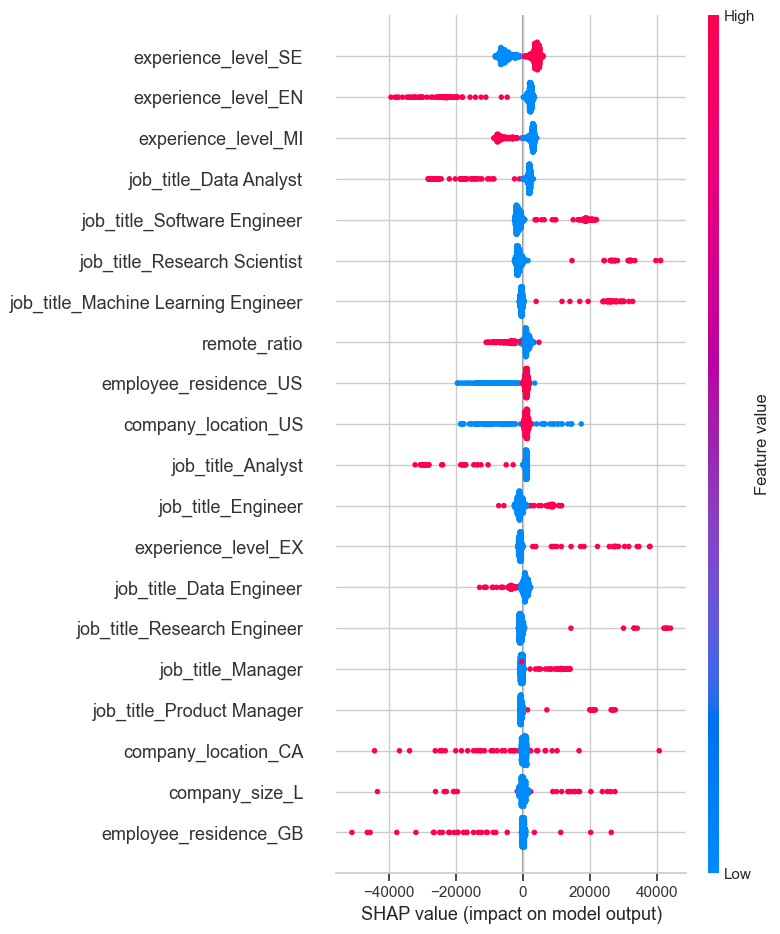


2. bar plot:


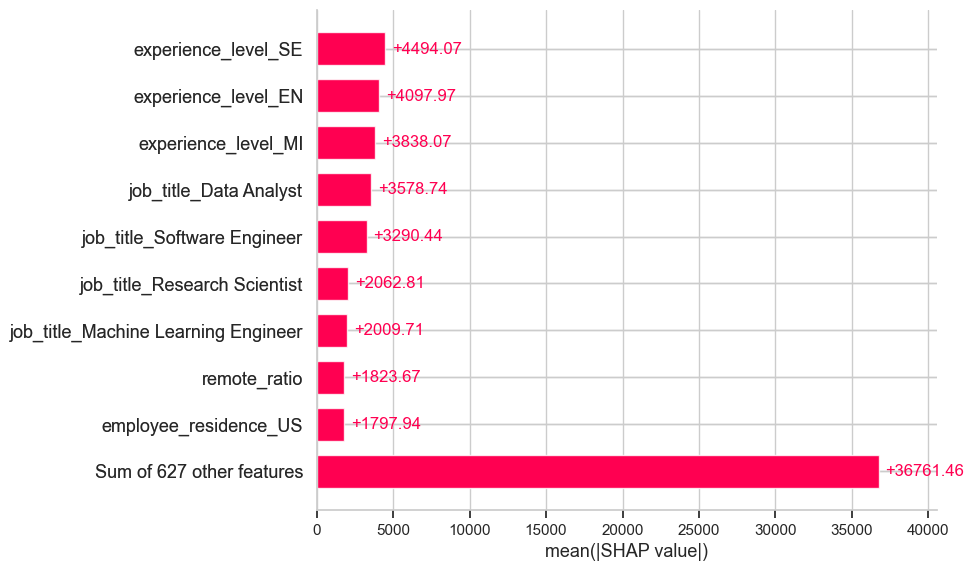


3.Graphique en cascade :


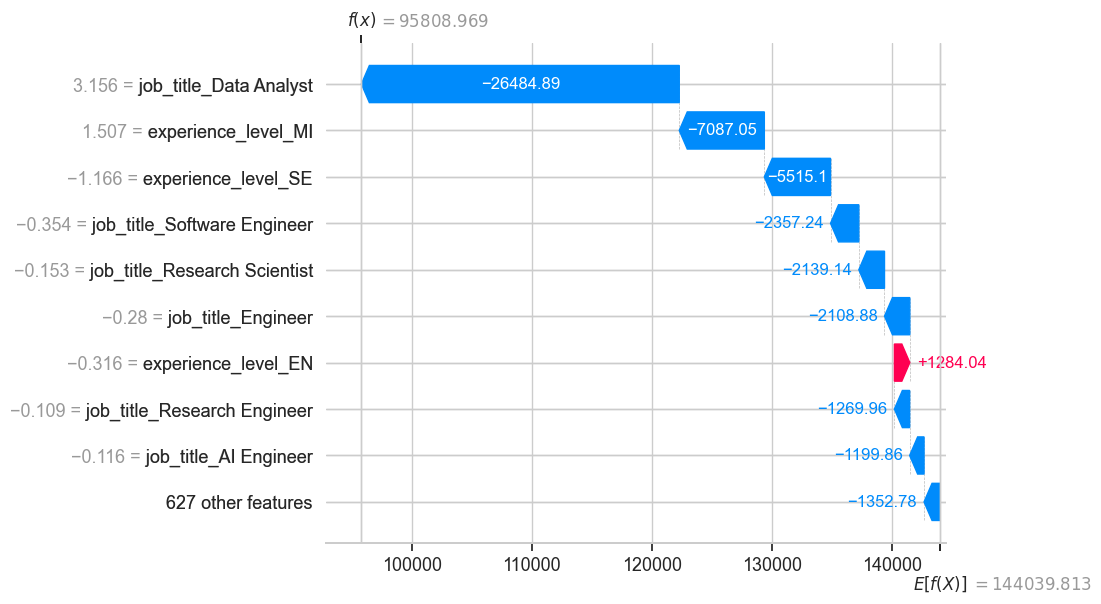

In [35]:
# analyse l'importance de feature en global
print("\n1. Schéma abstrait :")
shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=True)

print("\n2. bar plot:")
shap_exp = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_sample,
    feature_names=feature_names
)

shap.plots.bar(shap_exp, show=True)

print("\n3.Graphique en cascade :")
shap.plots.waterfall(shap_exp[0])